![Los Angeles skyline](la_skyline.jpg)

Los Angeles, California 😎. The City of Angels. Tinseltown. The Entertainment Capital of the World! 

Known for its warm weather, palm trees, sprawling coastline, and Hollywood, along with producing some of the most iconic films and songs. However, as with any highly populated city, it isn't always glamorous and there can be a large volume of crime. That's where you can help!

You have been asked to support the Los Angeles Police Department (LAPD) by analyzing crime data to identify patterns in criminal behavior. They plan to use your insights to allocate resources effectively to tackle various crimes in different areas.

## The Data

They have provided you with a single dataset to use. A summary and preview are provided below.

It is a modified version of the original data, which is publicly available from Los Angeles Open Data.

# crimes.csv

| Column     | Description              |
|------------|--------------------------|
| `'DR_NO'` | Division of Records Number: Official file number made up of a 2-digit year, area ID, and 5 digits. |
| `'Date Rptd'` | Date reported - MM/DD/YYYY. |
| `'DATE OCC'` | Date of occurrence - MM/DD/YYYY. |
| `'TIME OCC'` | In 24-hour military time. |
| `'AREA NAME'` | The 21 Geographic Areas or Patrol Divisions are also given a name designation that references a landmark or the surrounding community that it is responsible for. For example, the 77th Street Division is located at the intersection of South Broadway and 77th Street, serving neighborhoods in South Los Angeles. |
| `'Crm Cd Desc'` | Indicates the crime committed. |
| `'Vict Age'` | Victim's age in years. |
| `'Vict Sex'` | Victim's sex: `F`: Female, `M`: Male, `X`: Unknown. |
| `'Vict Descent'` | Victim's descent:<ul><li>`A` - Other Asian</li><li>`B` - Black</li><li>`C` - Chinese</li><li>`D` - Cambodian</li><li>`F` - Filipino</li><li>`G` - Guamanian</li><li>`H` - Hispanic/Latin/Mexican</li><li>`I` - American Indian/Alaskan Native</li><li>`J` - Japanese</li><li>`K` - Korean</li><li>`L` - Laotian</li><li>`O` - Other</li><li>`P` - Pacific Islander</li><li>`S` - Samoan</li><li>`U` - Hawaiian</li><li>`V` - Vietnamese</li><li>`W` - White</li><li>`X` - Unknown</li><li>`Z` - Asian Indian</li> |
| `'Weapon Desc'` | Description of the weapon used (if applicable). |
| `'Status Desc'` | Crime status. |
| `'LOCATION'` | Street address of the crime. |

In [62]:
# Re-run this cell
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
crimes = pd.read_csv("crimes.csv", dtype={"TIME OCC": str})
crimes.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA NAME,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Weapon Desc,Status Desc,LOCATION
0,220314085,2022-07-22,2020-05-12,1110,Southwest,THEFT OF IDENTITY,27,F,B,NaN,Invest Cont,2500 S SYCAMORE AV
1,222013040,2022-08-06,2020-06-04,1620,Olympic,THEFT OF IDENTITY,60,M,H,NaN,Invest Cont,3300 SAN MARINO ST
2,220614831,2022-08-18,2020-08-17,1200,Hollywood,THEFT OF IDENTITY,28,M,H,NaN,Invest Cont,1900 TRANSIENT
3,231207725,2023-02-27,2020-01-27,0635,77th Street,THEFT OF IDENTITY,37,M,H,NaN,Invest Cont,6200 4TH AV
4,220213256,2022-07-14,2020-07-14,0900,Rampart,THEFT OF IDENTITY,79,M,B,NaN,Invest Cont,1200 W 7TH ST


In [63]:
# Initial Data Cleaning
# First convert datatime variables to the proper type

crimes.columns = crimes.columns.str.replace(" ", "_")
crimes.columns = crimes.columns.str.lower()
crimes.columns = crimes.columns.str.strip()

crimes["date_rptd"] = crimes["date_rptd"].astype("datetime64")
crimes["date_occ"] = crimes["date_occ"].astype("datetime64")

print(crimes.dtypes)


dr_no                    int64
date_rptd       datetime64[ns]
date_occ        datetime64[ns]
time_occ                object
area_name               object
crm_cd_desc             object
vict_age                 int64
vict_sex                object
vict_descent            object
weapon_desc             object
status_desc             object
location                object
dtype: object


In [64]:
# Check if any data is missing

crimes.info()

# We find that the particular variables used to examine crime statistics have no missing values, therefore no further processing is done
# But as a note we see there are:
# 10 missing values in "vict_descent"
# 11 missing values in "vict_sex"



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185715 entries, 0 to 185714
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   dr_no         185715 non-null  int64         
 1   date_rptd     185715 non-null  datetime64[ns]
 2   date_occ      185715 non-null  datetime64[ns]
 3   time_occ      185715 non-null  object        
 4   area_name     185715 non-null  object        
 5   crm_cd_desc   185715 non-null  object        
 6   vict_age      185715 non-null  int64         
 7   vict_sex      185704 non-null  object        
 8   vict_descent  185705 non-null  object        
 9   weapon_desc   73502 non-null   object        
 10  status_desc   185715 non-null  object        
 11  location      185715 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(8)
memory usage: 17.0+ MB


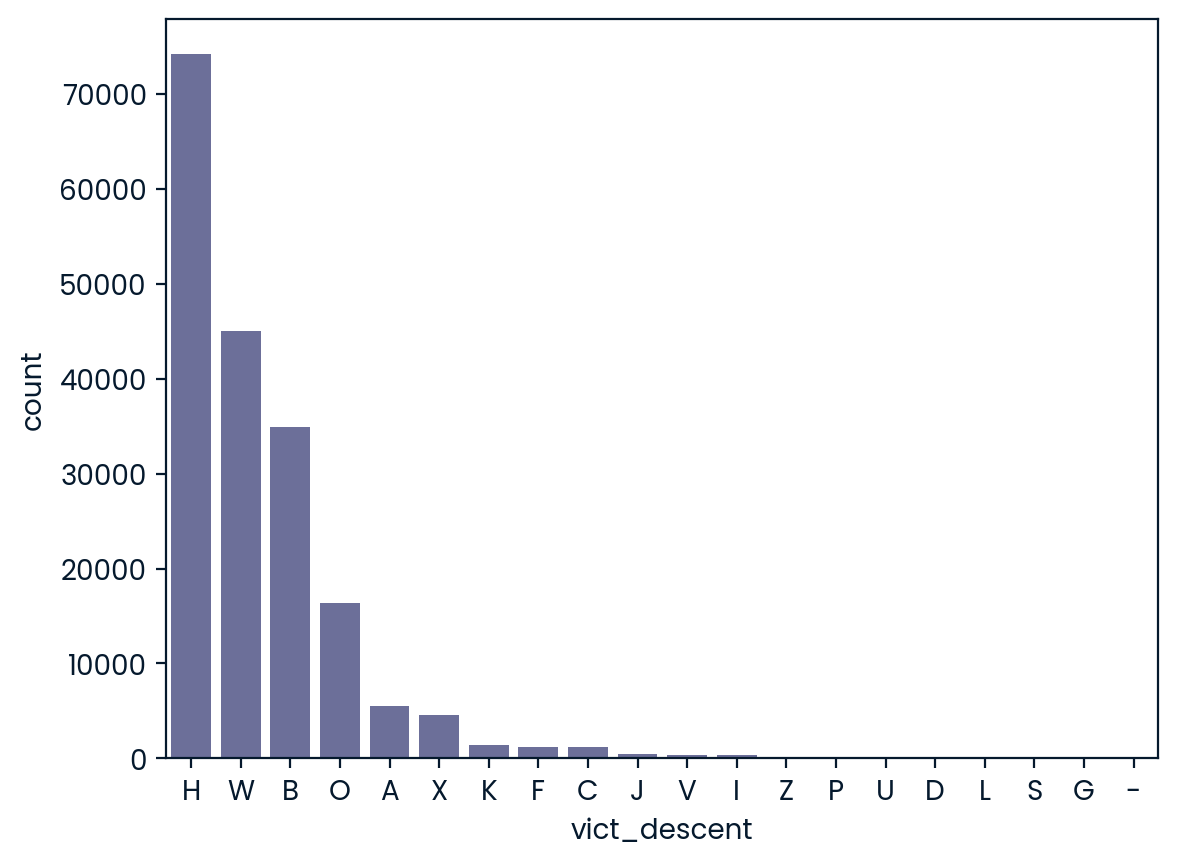

In [65]:

import seaborn as sns

# Examine crimes by ethnicity of victims
order_index = crimes["vict_descent"].value_counts().index
sns.countplot(data=crimes,x="vict_descent",order=order_index)
plt.show()

<class 'numpy.int64'>


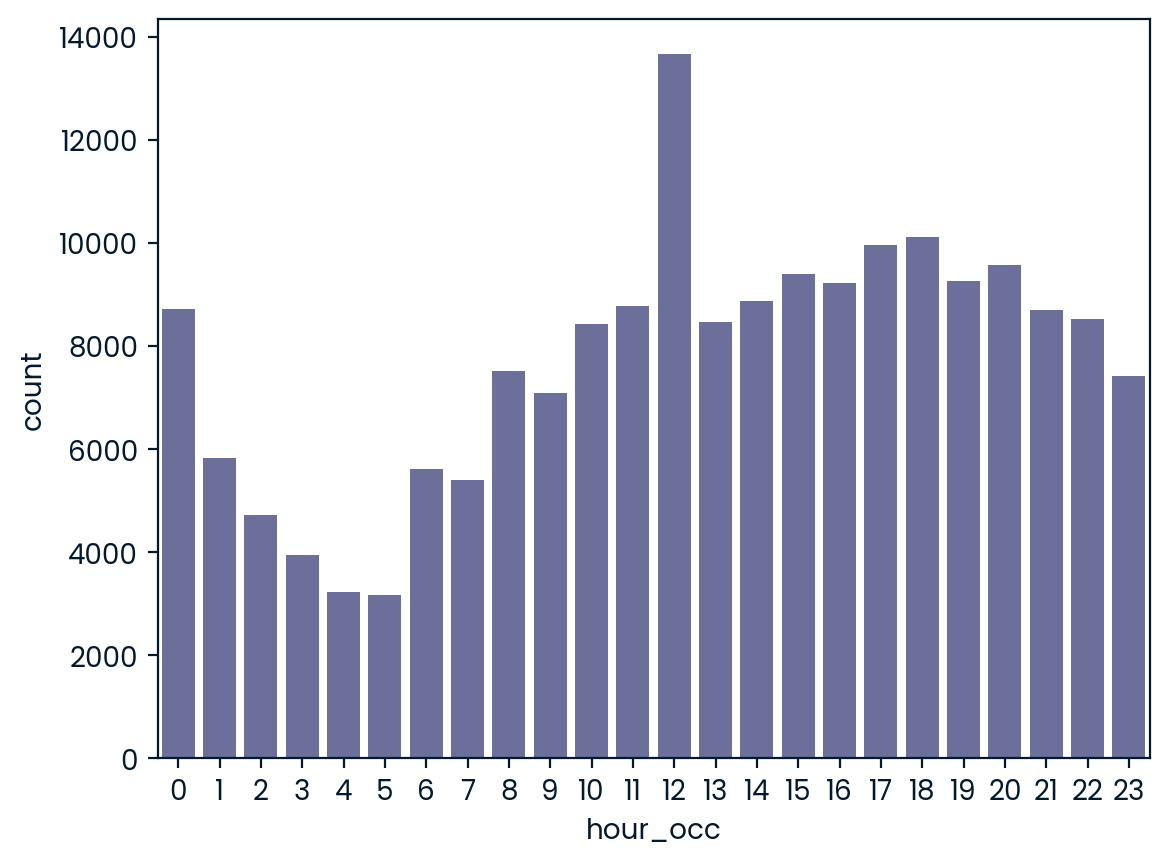

In [66]:
# Examine crimes by hour of day

# Add a new variable for hour of crime occurence
crimes["hour_occ"] = crimes["time_occ"].str[:2].astype(int)

# Create an index for hour for ordering purposes 
hour_index = list(range(24))
sns.countplot(data=crimes,x="hour_occ",order=hour_index)

# This code answers the actual "exam" question posed in the Project Instructions
peak_crime_hour = crimes["hour_occ"].mode()[0]
print(type(peak_crime_hour))

In [67]:
# Examine crimes by area, with particular attention foucssed on night / early morning

peak_night_crime_location = crimes.loc[crimes["hour_occ"].isin([0,1,2,3,22,23]) , "area_name"].value_counts().idxmax()
print(peak_night_crime_location)




Central


<class 'pandas.core.series.Series'>
26-34    47470
35-44    42157
45-54    28353
18-25    28291
55-64    20169
65+      14747
0-17      4528
Name: victim_age_categorized, dtype: int64


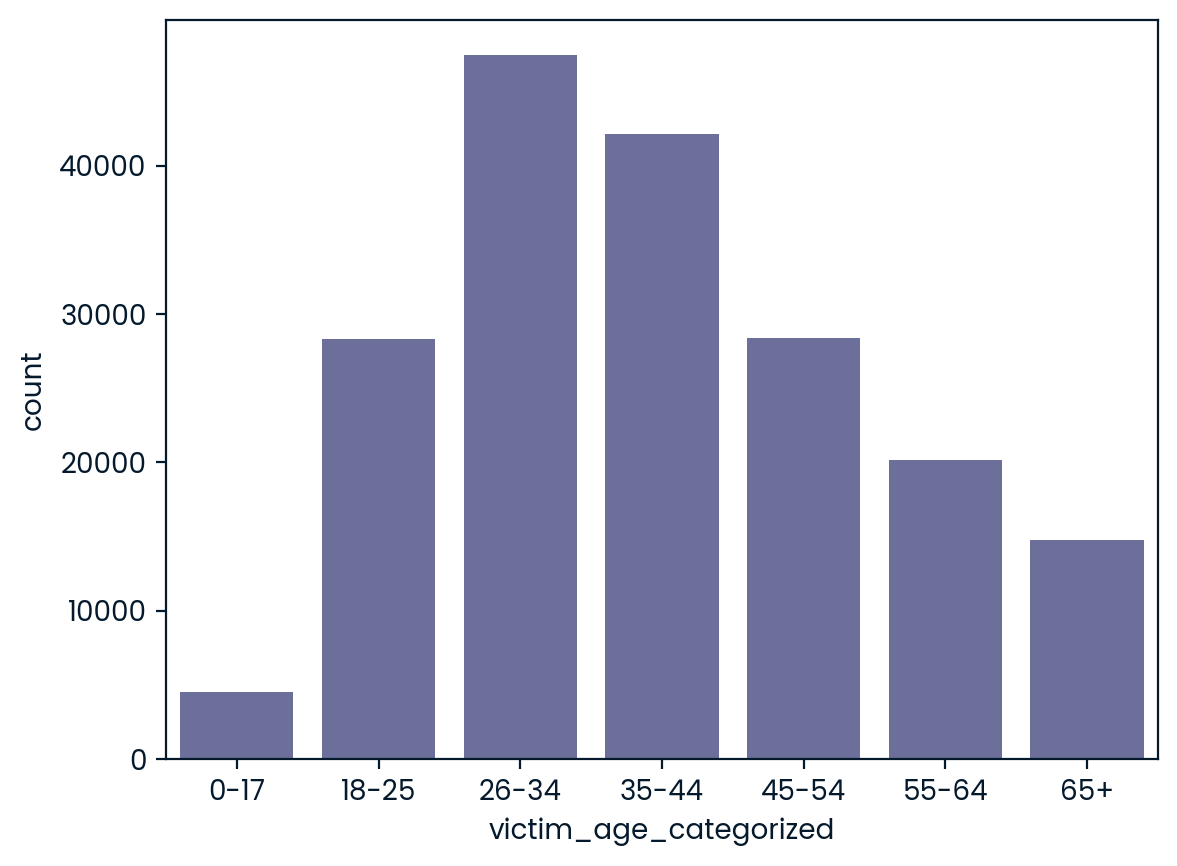

Rows that were not categrized: 0


,vict_age,victim_age_categorized
0,27,26-34
1,60,55-64
2,28,26-34
3,37,35-44
4,79,65+
...,...,...
185710,25,18-25
185711,23,18-25
185712,25,18-25
185713,29,26-34


In [68]:
# Examine distribution of ages of victims

#First group up ages into bins

age_bin_labels = ["0-17","18-25","26-34","35-44","45-54","55-64","65+"]
age_bins_edges = [0,18,26,35,45,55,65,float("inf")]
crimes["victim_age_categorized"] = pd.cut(crimes["vict_age"],labels=age_bin_labels,bins=age_bins_edges,right=False,include_lowest=True)

victim_ages = crimes["victim_age_categorized"].value_counts()
print(type(victim_ages))
print(victim_ages)


sns.countplot(data=crimes,x="victim_age_categorized",order=age_bin_labels)
plt.show()

# check that all rows got categroized
error_check = crimes["victim_age_categorized"].isin(age_bin_labels).sum()
print(f'Rows that were not categrized: {error_check-len(crimes)}')

crimes[["vict_age","victim_age_categorized"]]
